In [1]:
## 2026.02.11 using FineST env
## 2026.02.12 vilization cell type of each ROI
## 2026.03.04 woody_pro:: upload the HE-StarDist embedding and predict the cell type of NCRT_tumor1  
## 2026.03.06 woody_pro:: clearn code 
## 2026.03.13 update cell type level1: nanually make codex_meta_celltype_level1.csv 
## 2026.03.16 use valis to make registration [dont try]
## 2026.03.18 delete two subtypes, adjust scale factor by batch
## 2026.03.19 Train and using NCRT_train.ipynb
## 2026.03.23 Adjust file name and path, then adjust model to use level1 and level2, make model_train_validate.ipynb
## 2026.04.04 woody_pro: SeededNTM; make processing for x, add cv in training for tumor1
## 2026.04.06 Adjust loss function
## 2026.04.14 LLY update using UNI method, based on LOGO CV
## 2026.05.11 Use codex_meta_celltype_level012.csv, run Data_process_visualization.ipynb and demo_level012.sh, 
##            to get he_cell_coords/ and matched_features_tumor1_level012.npz
## 2026.05.11 add the prediction form Level1 directly
## 2026.05.21 copy form NCRT_train_validate_tumor1_cv_UNIlabel012.ipynb, adjust the code for Xenium data
## 2026.05.22 make the code clean, add the StarDist prediction, and adjust the code for Xenium data

In [24]:
import os
# Before other imports: PyTorch/torch.distributed may use /tmp; set NCRT_TMPDIR if quota is tight.
_nrtc_tmp = os.environ.get("NCRT_TMPDIR", os.path.join(os.path.expanduser("~"), "ssd2", "tmp"))
try:
    os.makedirs(_nrtc_tmp, exist_ok=True)
    os.environ["TMPDIR"] = _nrtc_tmp
    os.environ["TEMP"] = _nrtc_tmp
    os.environ["TMP"] = _nrtc_tmp
    import tempfile as _tf_nb
    _tf_nb.tempdir = _nrtc_tmp
except OSError:
    pass

import sys
import importlib
import pandas as pd
from pathlib import Path

## Add the code directory to Python path
path = '/home/lingyu/ssd2/Python/'
code_dir = f'{path}Hist2Pheno/code/Hist2Pheno_pkg/'
if code_dir not in sys.path:
    sys.path.insert(0, code_dir)

## Import (or reload) base module
# Do NOT `import model` — that binds the name ``model`` to the *module* and will shadow
# your trained ``torch.nn.Module`` after ``globals().update(LP)`` when this cell is re-run.
import base
import plot
import model as model_pkg
## Impost：Force reload base.py
importlib.reload(base)
importlib.reload(plot)
importlib.reload(model_pkg)

## Re-import the function (otherwise, still be old_version).
from base import (
    get_celltype_coords,
    divide_into_rois_by_parent,
    get_pixel_size,
    visualize_roi_cells,
    visualize_all_rois_with_he,
    visualize_all_rois,
    extract_and_save_celltype_by_tumorid,
    transformation_matrix_properties,
    invert_transformation_matrix,
    align_pcf_to_he_coordinates,
    add_pixel_coords,
    verify_transformation_alignment,
    merge_coordinates,
    analyze_and_filter_classes_by_gap,
    ImprovedMLPClassifier,
    load_embeddings,
    match_embeddings,
    prepare_matched_embeddings,
    evaluate,
    create_dataloaders,
    train_model,
    CellTypeDataset,
    evaluate_and_plot_on_all_data,
    align_matrix,
    match_StarCoords2ROI,
    match_celltype2stardist,
    merge_celltype_level12,
    make_PCF2HE_alignment,
    load_cell_pixcoords,load_hist_embeddings,
    match_hist2cell_matrix,
    make_PCF2HE2StarDist_alignment,
    save_hce_validation_metrics,
    split_train_test,
    prepare_data_leave_one_group_out,
    spatial_tile_groups_for_logo,
    loader_train_test,
    first_pth_tensor
    
)

from plot import (
    plot_celltype_distribution,
    visualize_all_celltype_distributions,
    plot_celltype_distribution,
    plot_celltype_spatial_distribution,
    plot_PCF_HE_counts,
    plot_WSI_counts,
    plot_cell_area_histogram,
    plot_confusion_matrix,
    plot_level1_spatial_distribution,
    plot_per_class_f1,
    plot_per_class_accuracy,
    plot_level1_accuracy_from_level2_predictions,
    mlp_collect_softmax_probs,
    plot_multiclass_roc_curves,
    plot_level1_roc_from_level2_scores,
    plot_level1_f1_from_level2_predictions,
    plot_level1_accuracy_from_level1_head,
    plot_level1_f1_from_level1_head,
    plot_level1_roc_from_level1_head
)

from model import (
    build_mlp_classifier,
    get_best_checkpoint_path,
    sync_best_mlp_from_logo_fold,
    train_and_save_model,
    infer_input_dim_and_num_classes,
    mode_validation,
    load_model_for_predict,
    train_and_save_model_from_split,
    mode_validation_from_split,
    train_hce_leave_one_group_out_cv,
    run_logo_cv_and_load_best_model,
    report_logo_cv_means_and_insample_eval,
    run_logo_cv_with_insample_report,
    run_stratified_kfold_cv_with_insample_report
)

## Import HAS_OPENSLIDE and HAS_TIFFFILE from base module for use in notebook
HAS_OPENSLIDE = base.HAS_OPENSLIDE
HAS_TIFFFILE = base.HAS_TIFFFILE

## Also import openslide module if available (needed for direct use in some cells)
if HAS_OPENSLIDE:
    import openslide
else:
    openslide = None

try:
    import tifffile
except ImportError:
    tifffile = None

print("Successfully reloaded functions from base.py")
print(f"openslide: {HAS_OPENSLIDE}, tifffile: {HAS_TIFFFILE}")


## reset pathway
# os.chdir(f'{path}Hist2Pheno/data')
os.chdir(f'{path}Hist2Pheno/data/Xemium/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases_Select4')   
therapy_data = 'VUILD107MA'
image_feature = f'sc_{therapy_data}'
therapy_model = f'{therapy_data}_project_all_UNI'
# segment_data1 = f'{therapy_data}_project - seg 1-14'
# segment_data2 = f'{therapy_data}_project - seg 15-28'
# export_data = 'export'
save_result = 'result'

stardist_data = 'StarDist_Segment'
# transfer_data = 'he_cell_coords'
# qupath_corner = 'QupathCorners'

Successfully reloaded functions from base.py
openslide: False, tifffile: True


In [3]:

## Result figures: name → filename under .../{therapy_model}/result (pass key to plot save_path)
from pathlib import Path

SELECT4_ROOT = (
    f"{path}Hist2Pheno/data/Xemium/weiqin/SpatialPF-NGenetics/"
    f"Spatial-PF-Processed/Data/Complete_Cases_Select4"
)
_result_dir = f"{SELECT4_ROOT}/{therapy_data}/{therapy_model}/{save_result}"

FIG = {
    # HE / HCE (insample validation)
    "conf_matrix_level2": "conf_matrix_level2.pdf",
    "conf_matrix_level1": "conf_matrix_level1.pdf",
    "conf_matrix_level1_L1head": "conf_matrix_level1_L1head.pdf",
    "f1_perclass_level2": "f1_perclass_level2.pdf",
    "f1_perclass_level1": "f1_perclass_level1.pdf",
    "f1_perclass_level1_L1head": "f1_perclass_level1_L1head.pdf",
    "celltype_valid_level2": "celltype_valid_level2.jpg",
    "celltype_true_level2" : "celltype_true_level2.jpg",
    "celltype_valid_level1": "celltype_valid_level1.jpg",
    "celltype_true_level1" : "celltype_true_level1.jpg",
    "validation_internal_metrics": "validation_internal_metrics.csv",
    # StarDist (all-data prediction)
    "stardist_pred_level2": "celltype_pred_stardist_level2.jpg",
    "stardist_true_level2": "celltype_true_stardist_level2.jpg",
    "stardist_pred_level1": "celltype_pred_stardist_level1.jpg",
    "stardist_true_level1": "celltype_true_stardist_level1.jpg",
    "acc_level2_stardist": "acc_level2_stardist.pdf",
    "acc_level1_stardist": "acc_level1_stardist.pdf",
    "acc_level1_stardist_L1head": "acc_level1_stardist_L1head.pdf",
    "conf_matrix_level2_stardist": "conf_matrix_level2_stardist.pdf",
    "conf_matrix_level1_stardist": "conf_matrix_level1_stardist.pdf",
    "f1_level2_stardist": "f1_level2_stardist.pdf",
    "f1_level1_stardist": "f1_level1_stardist.pdf",
    "f1_level1_stardist_L1head": "f1_level1_stardist_L1head.pdf",
    "roc_stardist_level2": "roc_stardist_level2.pdf",
    "roc_stardist_level1": "roc_stardist_level1.pdf",
    "roc_stardist_level1_L1head": "roc_stardist_level1_L1head.pdf",
}


def result_fig(name, mkdir=True):
    """Full path for a figure/metrics file in FIG (under _result_dir)."""
    if name not in FIG:
        raise KeyError(f"Unknown FIG key {name!r}; available: {sorted(FIG)}")
    out = Path(_result_dir) / FIG[name]
    if mkdir:
        out.parent.mkdir(parents=True, exist_ok=True)
    return str(out)

In [4]:
## CUDA/CPU sanity check for training setup
import os
import sys
import torch

# Default physical GPU index 2 (torch device string cuda:2). Override without editing:
#   export NCRT_CUDA_DEVICE=0
CUDA_DEVICE_INDEX = int(os.environ.get("NCRT_CUDA_DEVICE", "2"))

print(sys.executable)
print(
    f"torch {torch.__version__} | built with CUDA: {torch.version.cuda} | "
    f"cuda.is_available: {torch.cuda.is_available()}"
)

if torch.cuda.is_available():
    n_gpu = torch.cuda.device_count()
    if CUDA_DEVICE_INDEX < 0 or CUDA_DEVICE_INDEX >= n_gpu:
        raise RuntimeError(
            f"CUDA_DEVICE_INDEX={CUDA_DEVICE_INDEX} out of range; only {n_gpu} GPU(s) visible."
        )
    torch.cuda.set_device(CUDA_DEVICE_INDEX)
    device = torch.device(f"cuda:{CUDA_DEVICE_INDEX}")
    # Reproducibility-first: use deterministic cuDNN settings.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    amp_scaler = torch.amp.GradScaler("cuda")  # AMP only on CUDA
    print(
        f"Using device cuda:{CUDA_DEVICE_INDEX} | "
        f"{torch.cuda.get_device_name(CUDA_DEVICE_INDEX)}"
    )
else:
    allow_cpu = os.environ.get("NCRT_ALLOW_CPU_TRAIN", "").strip().lower() in ("1", "true", "yes")
    if allow_cpu:
        device, amp_scaler = torch.device("cpu"), None
        print("WARNING: CUDA unavailable, training on CPU (set NCRT_ALLOW_CPU_TRAIN=1).")
    else:
        raise RuntimeError(
            "CUDA unavailable. Please use a CUDA-enabled PyTorch build, "
            "or set NCRT_ALLOW_CPU_TRAIN=1 to run on CPU."
        )

if device.type == "cuda":
    print(f"device: {device} | {torch.cuda.get_device_name(CUDA_DEVICE_INDEX)}")
else:
    print(f"device: {device}")



## Reproducibility setup (run this first after kernel restart)
import os
import random
import numpy as np
import torch

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
# Needed by CUDA for deterministic GEMM on some ops.
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# Enforce deterministic behavior (may reduce speed).
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True)

print(f"Reproducibility configured with SEED={SEED}")

/ssd2/users/lingyu/conda_envs/SeededNTM/bin/python
torch 2.9.1+cu130 | built with CUDA: 13.0 | cuda.is_available: True
Using device cuda:2 | NVIDIA RTX PRO 6000 Blackwell Server Edition
device: cuda:2 | NVIDIA RTX PRO 6000 Blackwell Server Edition
Reproducibility configured with SEED=42


In [5]:
hist_embedding_dir = Path(f'{path}Hist2Pheno/data/Xemium/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases_Select4/{therapy_data}/{therapy_model}/ImgEmbeddings_all/sc_pth_16_16')
print(hist_embedding_dir)
tensor = first_pth_tensor(hist_embedding_dir)

/home/lingyu/ssd2/Python/Collaborate/esccAI/data/Xemiun/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases_Select4/VUILD107MA/VUILD107MA_project_all_UNI/ImgEmbeddings_all/sc_pth_16_16
Found file: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/Xemiun/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases_Select4/VUILD107MA/VUILD107MA_project_all_UNI/ImgEmbeddings_all/sc_pth_16_16/sc_VUILD107MA_15292.462890624987_5610.159667968753.pth
Loaded type: <class 'tuple'>
tensor.shape of the first .pth file: torch.Size([1, 1, 1024])


/home/lingyu/ssd2/Python/Hist2Pheno/data/Xemium/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases_Select4/VUILD107MA/VUILD107MA_project_all_UNI/ImgEmbeddings_all/sc_pth_16_16

Loaded type: <class 'tuple'>

tensor.shape of the first .pth file: torch.Size([1, 1, 1024])

## Cell Type Classification Model

Leave-one-group-out (LOGO) CV (sklearn `LeaveOneGroupOut` idea).  
Uses npz `matched_features_tumor1_logo.npz` with a `TumorID` column when available. If that column is constant for all rows (typical for tumor1-only CSV), the notebook **falls back to spatial tiles** on `X_pix_HE`×`Y_pix_HE` (`spatial_tile_groups_for_logo`).

In [6]:
## Match embeddings with celltype data by coordinates (stratified_kfold path)
cell_coords_path = f'{path}Hist2Pheno/data/Xemium/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases_Select4/{therapy_data}/{therapy_data}_cells_partitioned_by_annotation.csv'
hist_embedding_dir = Path(f'{path}Hist2Pheno/data/Xemium/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases_Select4/{therapy_data}/{therapy_model}/ImgEmbeddings_all/sc_pth_16_16')
matched_features_path = f'{path}Hist2Pheno/data/Xemium/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases_Select4/{therapy_data}/{therapy_data}_matched_features.npz'

# y = celltype (4 lineages); y_level1 = celltype_level1 (~33–45 final_CT). Do NOT set level1_name="celltype".
column_rename = base.XENIUM_COLUMN_RENAME_LINEAGE_Y_CT_LEVEL1  # final_lineage→celltype, final_CT→celltype_level1
level1_name = "celltype_level1"
match_tolerance = 1.0

# Delete {therapy_data}_matched_features.npz if you previously ran with wrong level1_name.
X, y, y_level1, y_level0, y_level01, y_level12, X_coords_matched = match_hist2cell_matrix(
    cell_coords_path=cell_coords_path,
    hist_embedding_dir=hist_embedding_dir,
    matched_features_path=matched_features_path,
    coord_cols=('X_pix_HE', 'Y_pix_HE'),
    tolerance=match_tolerance,
    pth_prefix=image_feature,
    level1_name=level1_name,
    column_rename=column_rename,
    auto_rename=False,
)

if X_coords_matched is not None:
    print(f"Matched coordinates shape: {X_coords_matched.shape}")


Loading celltype Ground Truth ...
  Column rename applied: {'final_lineage': 'celltype_level1', 'final_CT': 'celltype'}
  Loaded 30615 cells
  Cell types: 45 unique types

  ✓ matched_features cache found; skipping .pth directory load.
Loading pre-saved matched data...
  ⚠ No y_level0 / y_level01 / y_level12 in cache. Rebuild npz after adding celltype_level0 / celltype_level01 / celltype_level12 to the coords CSV.
  ✓ Loaded from /home/lingyu/ssd2/Python/Collaborate/esccAI/data/Xemiun/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases_Select4/VUILD107MA/VUILD107MA_matched_features.npz
  X shape: (30615, 1024)
  y shape: (30615,)
  Number of classes: 45
  ✓ Coordinates found in saved data
  ✓ Coordinates loaded: (30615, 2)
Matched coordinates shape: (30615, 2)


In [7]:
# Reuse LOGO filtering/encoding path as stratified_kfold prep; groups are placeholders here.
import numpy as np
from sklearn.preprocessing import StandardScaler

cv_data = prepare_data_leave_one_group_out(
    X, y, y_level1, groups=np.arange(X.shape[0], dtype=np.int64)
)

class_names = cv_data["class_names"]
class_names_level1 = cv_data["class_names_level1"]
le_level2 = cv_data["le_level2"]
le_level1 = cv_data["le_level1"]

scaler = StandardScaler()
scaler.fit(cv_data["X_f"])

# Coordinates aligned with filtered rows (same mask as rare-L2 filtering)
X_coords_plot = (
    X_coords_matched[cv_data["mask"]] if X_coords_matched is not None else None
)

# Optional: single random 70/30 split for comparison (disabled in CV flow)
RUN_RANDOM_TRAIN_TEST_SPLIT = False
if RUN_RANDOM_TRAIN_TEST_SPLIT:
    result = split_train_test(X, y, y_level1)
else:
    result = None


Leave-one-group-out prep (filtered data):
  Samples: 30614, features: 1024
  Level2 classes: 44, Level1 classes: 4
  Groups (for LOGO): 30614 unique


In [8]:
loaders = None
train_loader = val_loader = val_loader_eval = None
train_dataset = val_dataset = None
X_train_scaled = y_train_encoded = y_test_encoded = None
y_train_level1_encoded = y_test_level1_encoded = None
y_encoded_f = cv_data["y_encoded_f"]
y_level1_encoded_f = cv_data["y_level1_encoded_f"]

## MLP classifier

In [9]:
# Ablation: unified HCE weights under stratified_kfold CV
import os
import shutil
import pandas as pd

KFOLD_RESUME_FROM_CHECKPOINTS = True  # False=每个配置都重新训练；True/None=按已有 fold checkpoint 复用
AB_PATIENCE = 10
AB_MAX_EPOCHS = 50
AB_HIDDEN_DIMS = (1024, 512, 256)    # Model default
AB_CV_K = 5
AB_STRATIFY_TARGET = "joint"  # choices: level2 / level1 / joint

ABLATION_CONFIGS = [
    # {"tag": "B_equal", "hce_w1": 1.0, "hce_w2": 1.0, "hce_w12": 1.0},
    # {"tag": "C_emph_L1", "hce_w1": 2.0, "hce_w2": 1.0, "hce_w12": 1.0},
    {"tag": "D_emph_L2", "hce_w1": 1.0, "hce_w2": 2.0, "hce_w12": 1.0},
    # {"tag": "E_emph_agg", "hce_w1": 1.0, "hce_w2": 1.0, "hce_w12": 2.0},
]

ablation_runs = {}
rows = []

for cfg in ABLATION_CONFIGS:
    tag = cfg["tag"]

    ckpt_dir = os.path.join(
        path,
        "Hist2Pheno/data/Xemium/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases_Select4",
        therapy_data,
        therapy_model,
        "ablation_kfold_ckpts",
        tag,
    )

    print("\n" + "=" * 80)
    print(f"[Ablation][stratified_kfold] Running: {tag}")
    print("=" * 80)

    LP_i = run_stratified_kfold_cv_with_insample_report(
        device=device,
        cv_data=cv_data,
        scaler=scaler,
        class_names=class_names,
        evaluate=evaluate,
        path=path,
        therapy_data=therapy_data,
        therapy_model=therapy_model,
        hce_w1=cfg["hce_w1"],
        hce_w2=cfg["hce_w2"],
        hce_w12=cfg["hce_w12"],
        n_splits=AB_CV_K,
        stratify_target=AB_STRATIFY_TARGET,
        patience=AB_PATIENCE,
        max_epochs=AB_MAX_EPOCHS,
        loader_kwargs={"seed": SEED, "train_balance_sampler": False},
        resume_from_checkpoints=KFOLD_RESUME_FROM_CHECKPOINTS,
        kfold_checkpoint_dir=ckpt_dir,
        hidden_dims=AB_HIDDEN_DIMS,
    )

    ablation_runs[tag] = LP_i
    score_l4 = float(
        LP_i["val_macro_f1"]
        + LP_i["val_weighted_f1"]
        + LP_i["val_level1_macro_f1"]
        + LP_i["val_level1_weighted_f1"]
    )
    rows.append(
        {
            "tag": tag,
            "hce_w1": cfg["hce_w1"],
            "hce_w2": cfg["hce_w2"],
            "hce_w12": cfg["hce_w12"],
            "hidden_dims": str(AB_HIDDEN_DIMS),
            "l2_acc": float(LP_i["val_acc"]),
            "l2_macro_f1": float(LP_i["val_macro_f1"]),
            "l2_weighted_f1": float(LP_i["val_weighted_f1"]),
            "l1_acc": float(LP_i["val_level1_acc"]),
            "l1_macro_f1": float(LP_i["val_level1_macro_f1"]),
            "l1_weighted_f1": float(LP_i["val_level1_weighted_f1"]),
            "best_epoch": int(LP_i["best_epoch"]),
            "l4_kfold_select_score": score_l4,
        }
    )

AB_SUMMARY_DF = (
    pd.DataFrame(rows)
    .sort_values("l4_kfold_select_score", ascending=False)
    .reset_index(drop=True)
)
print("\nAblation summary (sorted by l4_kfold_select_score = L2/L1 macro+weighted):")
display(AB_SUMMARY_DF)

best_tag = AB_SUMMARY_DF.iloc[0]["tag"]
LP = ablation_runs[best_tag]

best_idx = AB_SUMMARY_DF["l4_kfold_select_score"].astype(float).idxmax()
assert AB_SUMMARY_DF.iloc[best_idx]["tag"] == best_tag

best_cfg = next(c for c in ABLATION_CONFIGS if c["tag"] == best_tag)
best_fold = LP["best_fold"]
best_fold_4term_score = float(
    best_fold["l2_macro_f1"]
    + best_fold["l2_weighted_f1"]
    + best_fold["l1_macro_f1"]
    + best_fold["l1_weighted_f1"]
)

print(f"Selected best config by l4_kfold_select_score: {best_tag}")
print(
    "  Best weights: "
    f"hce_w1={best_cfg['hce_w1']}, hce_w2={best_cfg['hce_w2']}, hce_w12={best_cfg['hce_w12']}"
)
print(
    "  Best fold checkpoint in selected config: "
    f"fold={best_fold['fold']}, 4-term score={best_fold_4term_score:.4f}, path={best_fold['checkpoint']}"
)

# Sync selected best fold to legacy best_mlp_gpu.pt path
sync_best_mlp_from_logo_fold(
    path,
    therapy_data,
    therapy_model,
    best_fold["checkpoint"],
)
print(f"  Synced best_mlp_gpu.pt: {get_best_checkpoint_path(path, therapy_data, therapy_model)}")

# For downstream cells
globals().update(LP)
globals()["AB_SUMMARY_DF"] = AB_SUMMARY_DF


[Ablation][stratified_kfold] Running: D_emph_L2
Train dataset size: 24491
Val dataset size: 6123
Batch size: 1024
Feature dimension: 1024

KFold fold 0: stratify='joint'
  Resume: checkpoint exists, skip training -> /ssd2/users/lingyu/Python/Collaborate/esccAI/data/Xemiun/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases_Select4/VUILD107MA/VUILD107MA_project_all_UNI/ablation_kfold_ckpts/D_emph_L2/hce_kfold_fold_0.pt
checkpoint_exists=True: loading checkpoint (no training): /ssd2/users/lingyu/Python/Collaborate/esccAI/data/Xemiun/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases_Select4/VUILD107MA/VUILD107MA_project_all_UNI/ablation_kfold_ckpts/D_emph_L2/hce_kfold_fold_0.pt
Loaded existing checkpoint metrics: accuracy=0.2427, weighted_f1=0.2530, macro_f1=0.1099
Train dataset size: 24491
Val dataset size: 6123
Batch size: 1024
Feature dimension: 1024

KFold fold 1: stratify='joint'
  Resume: checkpoint exists, skip training -> /ssd2/users/lingyu/Pytho

,tag,hce_w1,hce_w2,hce_w12,hidden_dims,l2_acc,l2_macro_f1,l2_weighted_f1,l1_acc,l1_macro_f1,l1_weighted_f1,best_epoch,l4_kfold_select_score
0,D_emph_L2,1.0,2.0,1.0,"(1024, 512, 256)",0.594891,0.712543,0.592156,0.922976,0.904041,0.922706,0,3.131446


Selected best config by l4_kfold_select_score: D_emph_L2
  Best weights: hce_w1=1.0, hce_w2=2.0, hce_w12=1.0
  Best fold checkpoint in selected config: fold=2, 4-term score=1.6266, path=/ssd2/users/lingyu/Python/Collaborate/esccAI/data/Xemiun/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases_Select4/VUILD107MA/VUILD107MA_project_all_UNI/ablation_kfold_ckpts/D_emph_L2/hce_kfold_fold_2.pt
sync_best_mlp_from_logo_fold: wrote '/home/lingyu/ssd2/Python/Collaborate/esccAI/data/VUILD107MA/VUILD107MA_project_all_UNI/best_mlp_gpu.pt' ← '/ssd2/users/lingyu/Python/Collaborate/esccAI/data/Xemiun/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases_Select4/VUILD107MA/VUILD107MA_project_all_UNI/ablation_kfold_ckpts/D_emph_L2/hce_kfold_fold_2.pt'
  Synced best_mlp_gpu.pt: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/VUILD107MA/VUILD107MA_project_all_UNI/best_mlp_gpu.pt


混淆矩阵里的 val_preds_level1 
- = 从 L2 predict（softmax）经层次加总矩阵得到的 L1 预测，不是「L1 独立 head 的直接分类」。
- 若要看 level1_head 自己的混淆矩阵，需要改成用 forward_heads 取 logits_l1 再 argmax（当前 LP 这条路径没有存那份预测）。

In [10]:
!pwd

/ssd2/users/lingyu/Python/Collaborate/esccAI/data/Xemiun/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases_Select4


Computing confusion matrix...
Figure saved to /home/lingyu/ssd2/Python/Collaborate/esccAI/data/Xemiun/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases_Select4/VUILD107MA/VUILD107MA_project_all_UNI/result/conf_matrix_level2.pdf


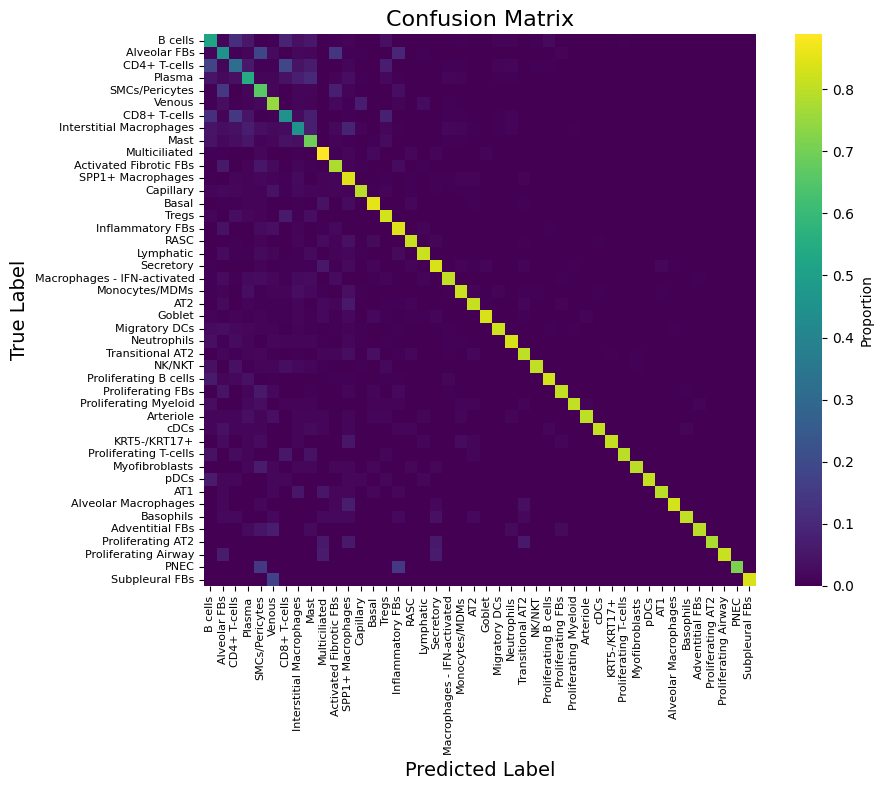

Computing confusion matrix...
Figure saved to /home/lingyu/ssd2/Python/Collaborate/esccAI/data/Xemiun/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases_Select4/VUILD107MA/VUILD107MA_project_all_UNI/result/conf_matrix_level1.pdf


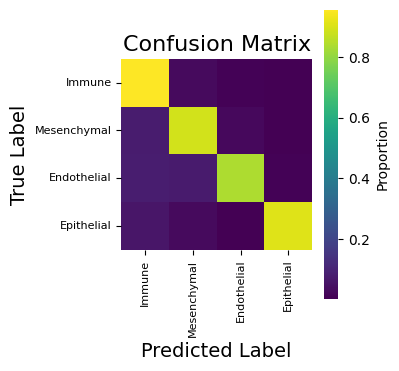

L1 agg vs L1 head agreement: 0.9599529626968054
Computing confusion matrix...
Figure saved to /home/lingyu/ssd2/Python/Collaborate/esccAI/data/Xemiun/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases_Select4/VUILD107MA/VUILD107MA_project_all_UNI/result/conf_matrix_level1_L1head.pdf


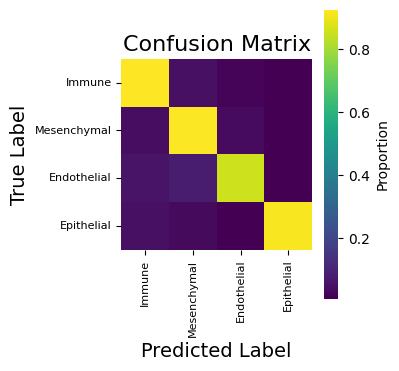

In [11]:
# Level2 confusion matrix
plot_confusion_matrix(
    val_labels,
    val_preds,
    class_names,
    figsize=(10, 8),
    save_path=result_fig("conf_matrix_level2"),
    # save_path=None
)

# Level1 confusion matrix
plot_confusion_matrix(
    val_labels_level1,
    val_preds_level1,
    class_names_level1,
    figsize=(4, 4),
    save_path=result_fig("conf_matrix_level1"),
    # save_path=None
)

# Optional: dedicated L1-head predictions (same LP run); safe if name not in globals yet
_val_l1_head = globals().get("val_preds_level1_head")
if _val_l1_head is None and isinstance(globals().get("LP"), dict):
    _val_l1_head = LP.get("val_preds_level1_head")
if _val_l1_head is not None:
    print("L1 agg vs L1 head agreement:", float((val_preds_level1 == _val_l1_head).mean()))
    plot_confusion_matrix(
        val_labels_level1,
        _val_l1_head,
        class_names_level1,
        figsize=(4, 4),
        save_path=result_fig("conf_matrix_level1_L1head"),
        # save_path=None,
    )
else:
    print(
        "Skip L1-head confusion matrix: val_preds_level1_head missing — importlib.reload(model) "
        "then re-run the CV/ablation cell (globals().update(LP))."
    )


In [12]:
## Save validation metrics (row = LOGO mean over folds; acc columns are NaN)
import numpy as np

# After ablation cell: logo_summary is in LP (kfold CV; key kept for compatibility).
logo_summary = globals().get("logo_summary")
if logo_summary is None and isinstance(globals().get("LP"), dict):
    logo_summary = LP.get("logo_summary")
if logo_summary is None:
    raise NameError("Run the ablation / CV cell first (globals().update(LP)) to define logo_summary.")

metrics_csv_path = result_fig("validation_internal_metrics")

hce_w1_used = globals().get("hce_w1", 1.0)
hce_w2_used = globals().get("hce_w2", 1.0)
hce_w12_used = globals().get("hce_w12", 2.0)
mean_best_epoch = int(round(float(np.mean([f["best_epoch"] for f in logo_summary["folds"]]))))

metrics_df, combined_df = save_hce_validation_metrics(
    val_acc=float("nan"),
    val_macro_f1=logo_summary["l2_macro_f1_mean"],
    val_weighted_f1=logo_summary["l2_weighted_f1_mean"],
    val_level1_acc=float("nan"),
    val_level1_macro_f1=logo_summary["l1_macro_f1_mean"],
    val_level1_weighted_f1=logo_summary["l1_weighted_f1_mean"],
    class_names=class_names if "class_names" in globals() else None,
    class_names_level1=class_names_level1 if "class_names_level1" in globals() else None,
    best_epoch=mean_best_epoch,
    hce_lambda=None,
    hce_w1=hce_w1_used,
    hce_w2=hce_w2_used,
    hce_w12=hce_w12_used,
    therapy_data=f"{therapy_data}_tumor1_LOGO",
    metrics_csv_path=metrics_csv_path,
    # metrics_csv_path=None,
)


Current run metrics:
             timestamp            therapy_data  best_epoch hce_lambda  hce_w1  \
0  2026-05-22 16:16:05  VUILD107MA_tumor1_LOGO           0       None     1.0   

   hce_w2  hce_w12  val_l2_accuracy  val_l2_macro_f1  val_l2_weighted_f1  \
0     2.0      1.0              NaN         0.115453            0.262392   

   val_l1_accuracy  val_l1_macro_f1  val_l1_weighted_f1  num_l2_classes  \
0              NaN         0.554398            0.674044              44   

   num_l1_classes  
0               4  

Saved comparison table to: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/Xemiun/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases_Select4/VUILD107MA/VUILD107MA_project_all_UNI/result/validation_internal_metrics.csv
Total rows: 5


Visualizing per-class performance...
  ✓ Computed metrics for 44 classes
Figure saved to /home/lingyu/ssd2/Python/Collaborate/esccAI/data/Xemiun/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases_Select4/VUILD107MA/VUILD107MA_project_all_UNI/result/f1_perclass_level2.pdf


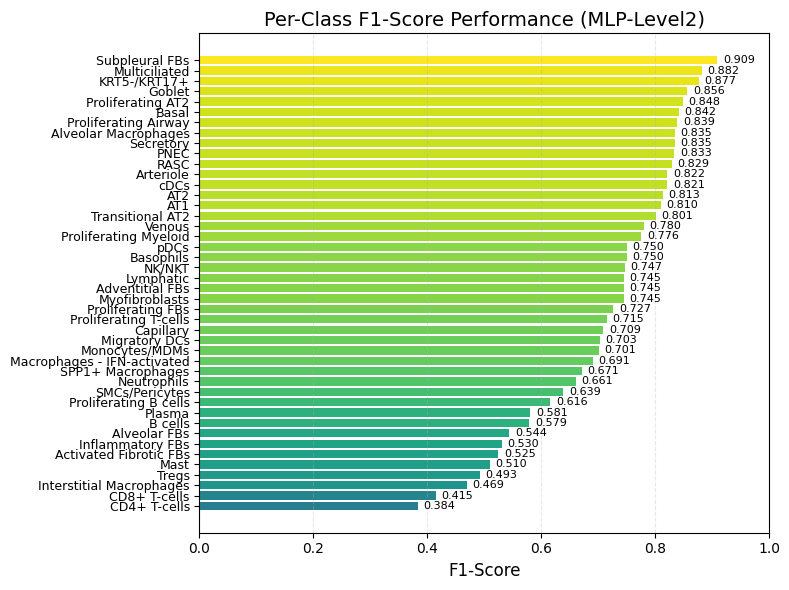


Model Summary:
  Device: cuda:2
  Total classes (before filtering): 44
  Actual classes in test set: 44
  Feature dimension: 1024
  Model parameters: 1,721,648
  Best epoch: 0
  Test Accuracy: 0.5949
  Test Macro F1: 0.7125
  Test Weighted F1: 0.5922
Visualizing per-class performance...
  ✓ Computed metrics for 4 classes
Figure saved to /home/lingyu/ssd2/Python/Collaborate/esccAI/data/Xemiun/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases_Select4/VUILD107MA/VUILD107MA_project_all_UNI/result/f1_perclass_level1.pdf


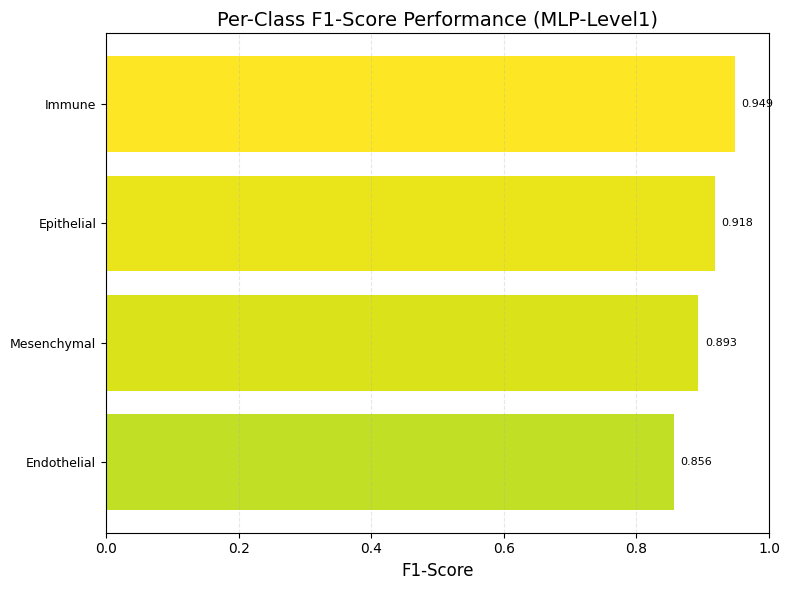


Model Summary:
  Device: cuda:2
  Total classes (before filtering): 4
  Actual classes in test set: 4
  Feature dimension: 1024
  Model parameters: 1,721,648
  Best epoch: 0
  Test Accuracy: 0.9230
  Test Macro F1: 0.9040
  Test Weighted F1: 0.9227
Visualizing per-class performance...
  ✓ Computed metrics for 4 classes
Figure saved to /home/lingyu/ssd2/Python/Collaborate/esccAI/data/Xemiun/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases_Select4/VUILD107MA/VUILD107MA_project_all_UNI/result/f1_perclass_level1_L1head.pdf


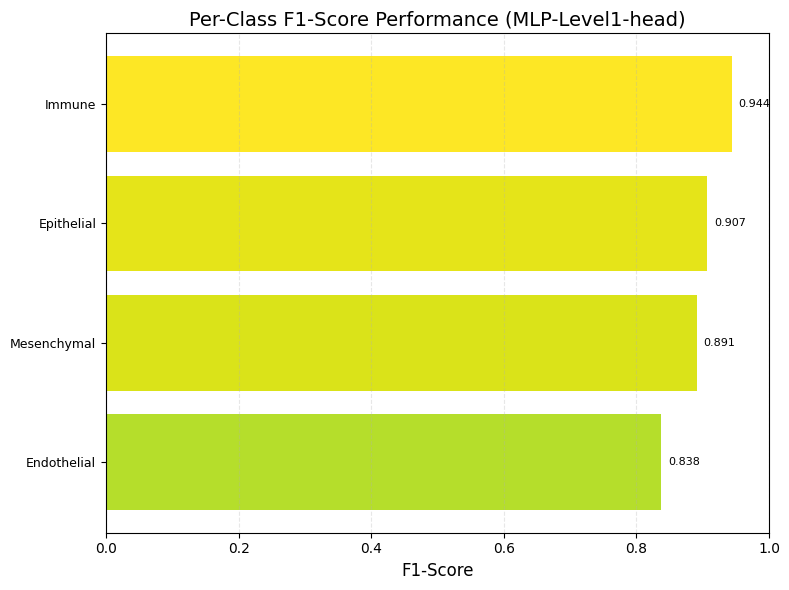


Model Summary:
  Device: cuda:2
  Total classes (before filtering): 4
  Actual classes in test set: 4
  Feature dimension: 1024
  Model parameters: 1,721,648
  Best epoch: 0
  Test Accuracy: 0.9230
  Test Macro F1: 0.9040
  Test Weighted F1: 0.9227


In [13]:
# Per-class F1 for level2
metrics_df_level2 = plot_per_class_f1(
    val_labels,
    val_preds,
    class_names,
    model=model,
    device=device,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    input_dim=input_dim,
    best_epoch=best_epoch,
    test_acc=val_acc,
    test_macro_f1=val_macro_f1,
    test_weighted_f1=val_weighted_f1,
    model_name="MLP-Level2",
    y_sort_by="f1_asc",
    save_path=result_fig("f1_perclass_level2"),
    # save_path=None
)

# Per-class F1 for level1
metrics_df_level1 = plot_per_class_f1(
    val_labels_level1,
    val_preds_level1,
    class_names_level1,
    model=model,
    device=device,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    input_dim=input_dim,
    best_epoch=best_epoch,
    test_acc=val_level1_acc,
    test_macro_f1=val_level1_macro_f1,
    test_weighted_f1=val_level1_weighted_f1,
    model_name="MLP-Level1",
    y_sort_by="f1_asc",
    save_path=result_fig("f1_perclass_level1"),
    # save_path=None
)

# Per-class F1 for level1
_val_l1_head_f1 = globals().get("val_preds_level1_head")
if _val_l1_head_f1 is None and isinstance(globals().get("LP"), dict):
    _val_l1_head_f1 = LP.get("val_preds_level1_head")
if _val_l1_head_f1 is not None:
    metrics_df_level1_head = plot_per_class_f1(
        val_labels_level1,
        _val_l1_head_f1,
        class_names_level1,
        model=model,
        device=device,
        train_dataset=train_dataset,
        val_dataset=val_dataset,
        input_dim=input_dim,
        best_epoch=best_epoch,
        test_acc=val_level1_acc,
        test_macro_f1=val_level1_macro_f1,
        test_weighted_f1=val_level1_weighted_f1,
        model_name="MLP-Level1-head",
        y_sort_by="f1_asc",
        save_path=result_fig("f1_perclass_level1_L1head"),
        # save_path=None
    )
else:
    print(
        "Skip L1-head per-class F1: val_preds_level1_head missing — importlib.reload(model) "
        "then re-run the CV/ablation cell (globals().update(LP))."
    )


  Using provided X and y...
  X_all_scaled shape: (30614, 1024)
  y_all_encoded shape: (30614,)
  ✓ Final y_all_encoded dtype: int64
X_all_scaled:  (30614, 1024)
y_all_encoded:  (30614,)
  Total samples: 30614
  DataLoader batch_size: 1024, num_workers: 4



Final Performance on All Data:
  Accuracy: 0.5950
  Macro F1-score: 0.7128
  Weighted F1-score: 0.5922
all_preds:  (30614,)
unique_labels:  (44,)

Detailed Classification Report:
  Number of classes: 44
                             precision    recall  f1-score   support

                        AT1       0.82      0.80      0.81        59
                        AT2       0.81      0.81      0.81       228
     Activated Fibrotic FBs       0.39      0.78      0.52       745
            Adventitial FBs       0.70      0.80      0.74        44
               Alveolar FBs       0.69      0.45      0.54      3786
       Alveolar Macrophages       0.84      0.83      0.83        58
                  Arteriole       0.84      0.80      0.82        95
                    B cells       0.65      0.52      0.58      4254
                      Basal       0.83      0.85      0.84       441
                  Basophils       0.70      0.80      0.75        56
               CD4+ T-cells       0.

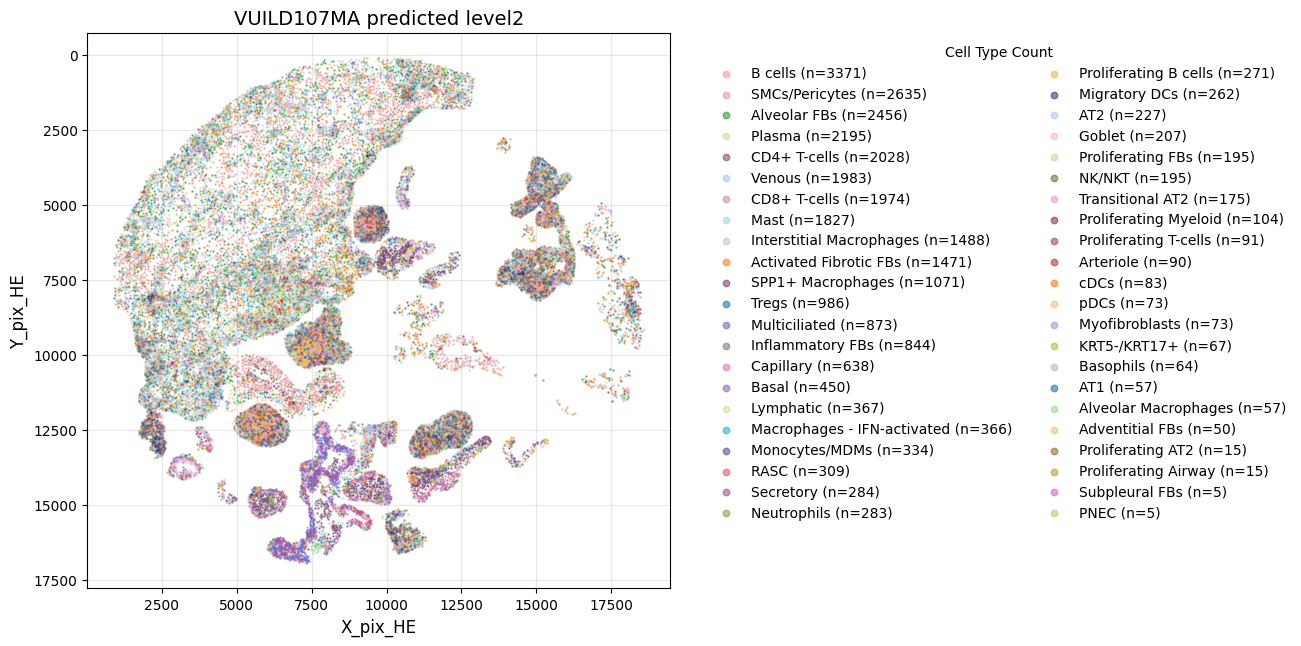


Plotting spatial distribution of TRUE level2 cell types...
Number of valid data points: 30614
Number of cell types: 44


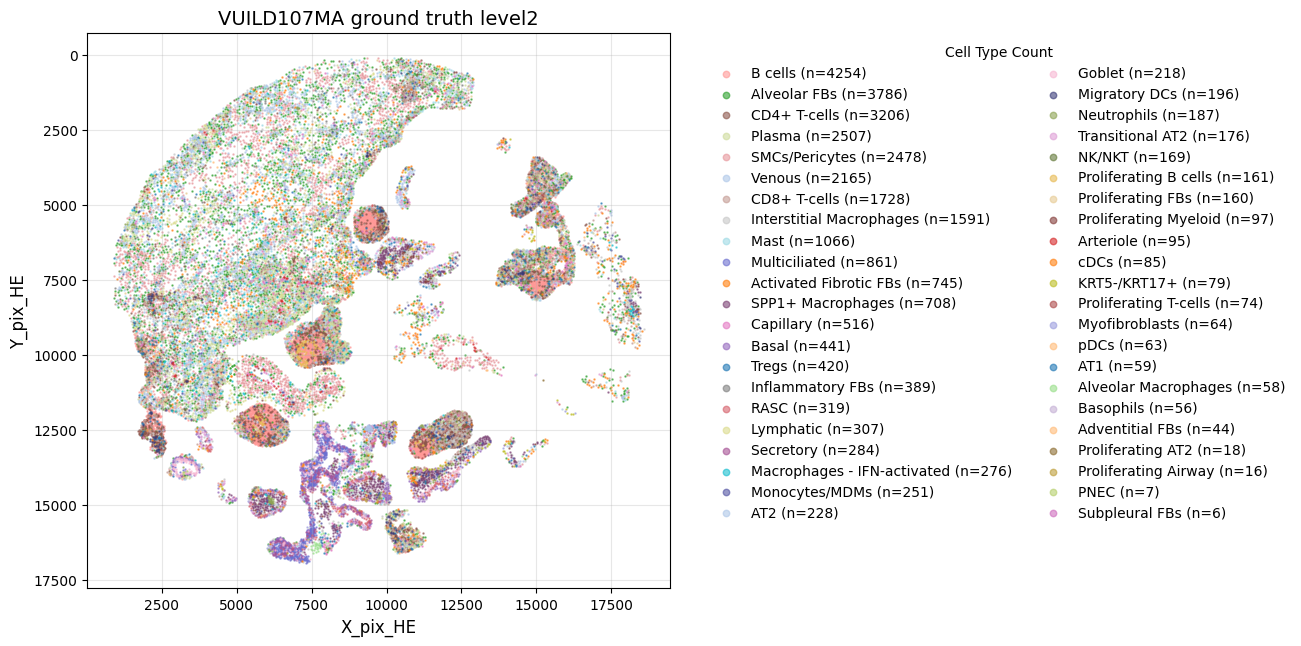

In [14]:
## Evaluate on all data: level2 spatial — predicted vs ground truth
# Rows must match cv_data filter and scaler fit on X_f.
all_acc, all_macro_f1, all_weighted_f1, all_preds, all_labels = evaluate_and_plot_on_all_data(
    model=model,
    matched_features_path="",
    class_names=class_names,
    evaluate=evaluate,
    plot_celltype_spatial_distribution=plot_celltype_spatial_distribution,
    CellTypeDataset=CellTypeDataset,
    device=device,
    scaler=scaler,
    val_loader=val_loader if "val_loader" in globals() else None,
    X=cv_data["X_f"],
    y=cv_data["y_f"],
    y_encoded=cv_data["y_encoded_f"],
    X_coords_matched=X_coords_plot if "X_coords_plot" in globals() else None,
    celltype_pred_dir=result_fig("celltype_valid_level2"),
    celltype_true_dir=result_fig("celltype_true_level2"),
    spatial_plot_mode="pred_true_l2",
    spatial_color_scheme="xenium_ct",
    spatial_title_pred_l2=f"{therapy_data} predicted level2",
    spatial_title_true_l2=f"{therapy_data} ground truth level2",
    celltype_pixel_NCRT_tumor1=celltype_pixel_NCRT_tumor1 if "celltype_pixel_NCRT_tumor1" in globals() else None,
)


  Level1 spatial plot: Xenium lineage colors (final_lineage palette).
Number of valid data points: 30614
Number of cell types: 4


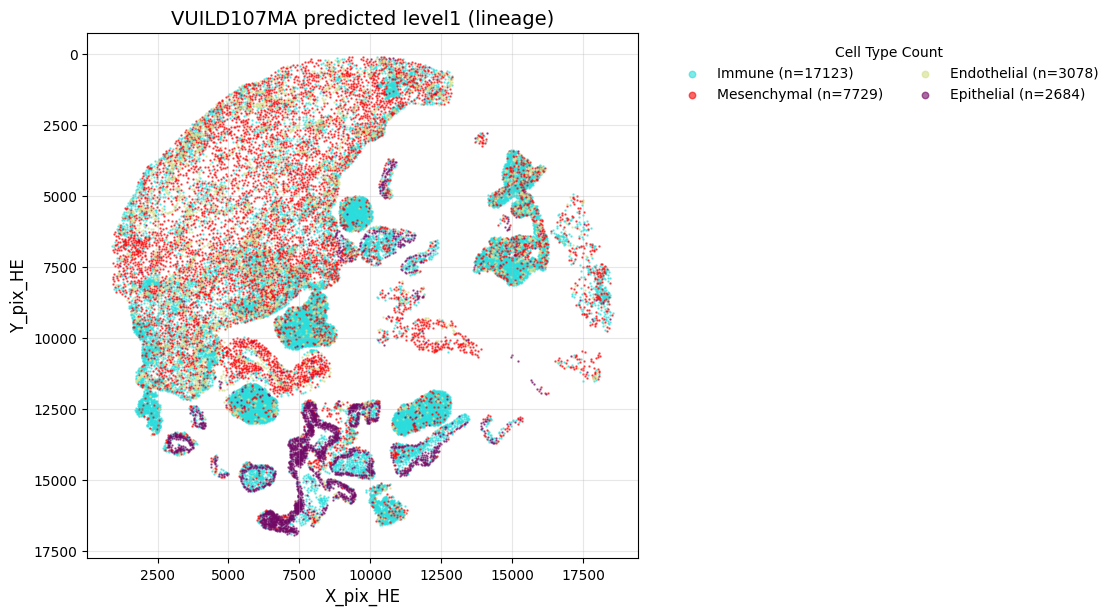

  Saved level1 predicted spatial plot: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/Xemiun/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases_Select4/VUILD107MA/VUILD107MA_project_all_UNI/result/celltype_valid_level1.jpg
Number of valid data points: 30614
Number of cell types: 4


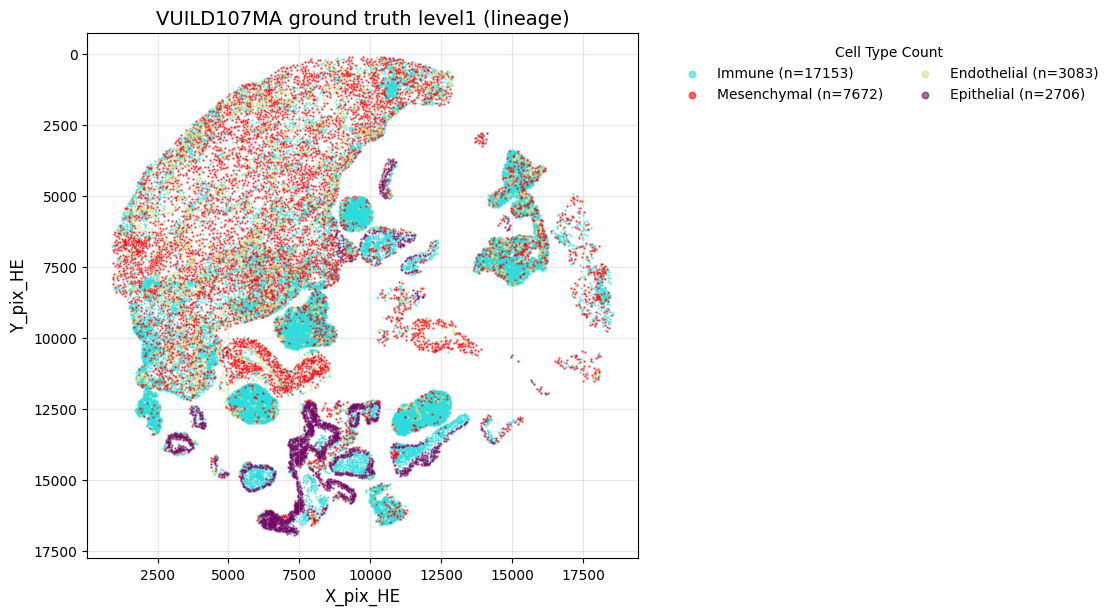

  Saved level1 true spatial plot: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/Xemiun/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases_Select4/VUILD107MA/VUILD107MA_project_all_UNI/result/celltype_true_level1.jpg


In [15]:
plot_level1_spatial_distribution(
    matched_features_path=matched_features_path,
    all_preds=all_preds,
    class_names_level1=class_names_level1,
    class_names=class_names,
    y_encoded_f=y_encoded_f,
    y_level1_encoded_f=y_level1_encoded_f,
    plot_celltype_spatial_distribution=plot_celltype_spatial_distribution,
    save_path_pred=result_fig("celltype_valid_level1"),
    save_path_true=result_fig("celltype_true_level1"),
    spatial_color_scheme="xenium_lineage",
    title_pred=f"{therapy_data} predicted level1 (lineage)",
    title_true=f"{therapy_data} ground truth level1 (lineage)",
    fig_size=(10, 8),
    show=True,
    X_coords_matched=X_coords_plot if "X_coords_plot" in globals() else None,
    y_level1_f=cv_data["y_level1_f"],
)


## Predict StarDist

In [16]:
## Load best model for StarDist prediction.
_star_ckpt = None
if isinstance(globals().get("LP"), dict):
    _bf = LP.get("best_fold")
    if isinstance(_bf, dict):
        _star_ckpt = _bf.get("checkpoint")

model_star = load_model_for_predict(
    path,
    therapy_data,
    therapy_model,
    parent_dir=True,
    checkpoint_path=_star_ckpt,
    device=device if "device" in globals() else None,
)


Loading best model for StarDist prediction...
  Checkpoint file: /ssd2/users/lingyu/Python/Collaborate/esccAI/data/Xemiun/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases_Select4/VUILD107MA/VUILD107MA_project_all_UNI/ablation_kfold_ckpts/D_emph_L2/hce_kfold_fold_2.pt
  Inferred hidden_dims from checkpoint: [1024, 512, 256]
✓ StarDist model loaded


In [17]:
hist_embedding_stardist_dir = Path(
    f'{path}Hist2Pheno/data/Xemium/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/'
    f'Data/Complete_Cases_Select4/{therapy_data}/{therapy_model}/ImgEmbeddings_all_stardist/sc_pth_16_16'
)
select4_sample_dir = f'{path}Hist2Pheno/data/Xemium/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases_Select4/{therapy_data}'
stardist_raw_path = f'{select4_sample_dir}/{therapy_data}_Float_prob001_nms_03.csv'
xenium_cell_path = f'{select4_sample_dir}/{therapy_data}_cells_partitioned_by_annotation.csv'
celltype_pixel_stardist_path = f'{select4_sample_dir}/{therapy_data}_stardist_cells_matched.csv'
matched_features_stardist_path = f"{select4_sample_dir}/{therapy_data}_matched_features_stardist.npz"

# 与前面 HE 的 match 一致；若未先跑 HE 单元格，则用默认列名
level1_name = globals().get("level1_name", "celltype_level1")
_column_rename = globals().get("column_rename", base.XENIUM_COLUMN_RENAME_LINEAGE_Y_CT_LEVEL1)
match_tolerance = 1.0

celltype_xenium = load_cell_pixcoords(xenium_cell_path, column_rename=_column_rename, auto_rename=False)
star_raw = pd.read_csv(stardist_raw_path)
celltype_pixel_NCRT_stardist = match_celltype2stardist(
    celltype_xenium,
    star_raw,
    celltype_pixel_coords_cols=("X_pix_HE", "Y_pix_HE"),
    stardist_pixel_coords_cols=("centroid_x", "centroid_y"),
)
celltype_pixel_NCRT_stardist = celltype_pixel_NCRT_stardist.dropna(subset=["centroid_x", "centroid_y"])
celltype_pixel_NCRT_stardist.to_csv(celltype_pixel_stardist_path, index=False)
print(f"Saved StarDist matched cells: {celltype_pixel_stardist_path}  shape={celltype_pixel_NCRT_stardist.shape}")

X_star, y_star, y_star_level1, y_star_level0, y_star_level01, y_star_level12, X_coords_star = match_hist2cell_matrix(
    cell_coords_path=celltype_pixel_stardist_path,
    hist_embedding_dir=hist_embedding_stardist_dir,
    matched_features_path=matched_features_stardist_path,
    coord_cols=("centroid_x", "centroid_y"),   # StarDist coordinates
    tolerance=match_tolerance,
    pth_prefix=f"sc_{therapy_data}",
    level1_name=level1_name,
    column_rename=None,
    auto_rename=False,
)


Loading celltype Ground Truth ...
  Column rename applied: {'final_lineage': 'celltype_level1', 'final_CT': 'celltype'}
  Loaded 30615 cells
  Cell types: 45 unique types

celltype_pixel_coords shape: (30615, 2)
stardist_pixel_coords shape: (105857, 2)
Building KDTree for star_coords...
Finding 100 nearest neighbors for each celltype point...


Nearest neighbor search completed. Distance matrix shape: (30615, 100)

Using greedy nearest neighbor matching...
Matched 30615 points
Matched distance: Mean, Median, Max: 13.00, 10.33, 166.97

Matched points summary:
  Total points in celltype_pixel_coords: 30615
  Matched points: 30615
  Unmatched points: 0
Matched of PCF-HE-StarDist: (30615, 21)
Saved StarDist matched cells: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/Xemiun/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases_Select4/VUILD107MA/VUILD107MA_stardist_cells_matched.csv  shape=(30615, 21)
Loading celltype Ground Truth ...
  Loaded 30615 cells
  Cell types: 45 unique types

  ✓ matched_features cache found; skipping .pth directory load.
Loading pre-saved matched data...
  ⚠ No y_level0 / y_level01 / y_level12 in cache. Rebuild npz after adding celltype_level0 / celltype_level01 / celltype_level12 to the coords CSV.
  ✓ Loaded from /home/lingyu/ssd2/Python/Collaborate/esccAI/data/Xemiun/weiqin/SpatialP

  Loading data from matched_features_path...
  ✓ Loaded X from /home/lingyu/ssd2/Python/Collaborate/esccAI/data/Xemiun/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases_Select4/VUILD107MA/VUILD107MA_matched_features_stardist.npz: (30615, 1024)
  ✓ Loaded y from /home/lingyu/ssd2/Python/Collaborate/esccAI/data/Xemiun/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases_Select4/VUILD107MA/VUILD107MA_matched_features_stardist.npz: (30615,), dtype: <U27
  ⚠ prediction_only=True: Labels will be used for visualization only, not for evaluation.
  ✓ Keeping labels as strings for visualization (no encoding needed)
  ✓ Scaled X using provided scaler
  X_all_scaled shape: (30615, 1024)
  No labels available - prediction mode only
X_all_scaled:  (30615, 1024)
dummy_labels:  (30615,)
  Total samples: 30615
  DataLoader batch_size: 1024, num_workers: 4
  Predicting on new data (no labels for evaluation)...


Predicting: 100%|██████████| 30/30 [00:00<00:00, 82.10it/s]



Prediction completed:
  Total predictions: 30615
  Predicted classes: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43]
  ✓ Using original labels for visualization: 30615 labels
  ⚠ 1 true labels are not in class_names; excluding them from metric computation.
  ✓ Computed metrics in prediction_only mode from aligned true labels: acc=0.3249, macro_f1=0.2222, weighted_f1=0.3261

Preparing spatial distribution plot...
  Matching predictions with coordinates...
  ✓ Loaded coordinates from /home/lingyu/ssd2/Python/Collaborate/esccAI/data/Xemiun/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases_Select4/VUILD107MA/VUILD107MA_matched_features_stardist.npz: (30615, 2)
  Coordinates shape: (30615, 2)
  Predictions shape: (30615,)
  ✓ Created prediction DataFrame with 30615 cells

Plotting spatial distribution of PREDICTED level2 cell types...
Number of valid data points: 30615
Number of cell t

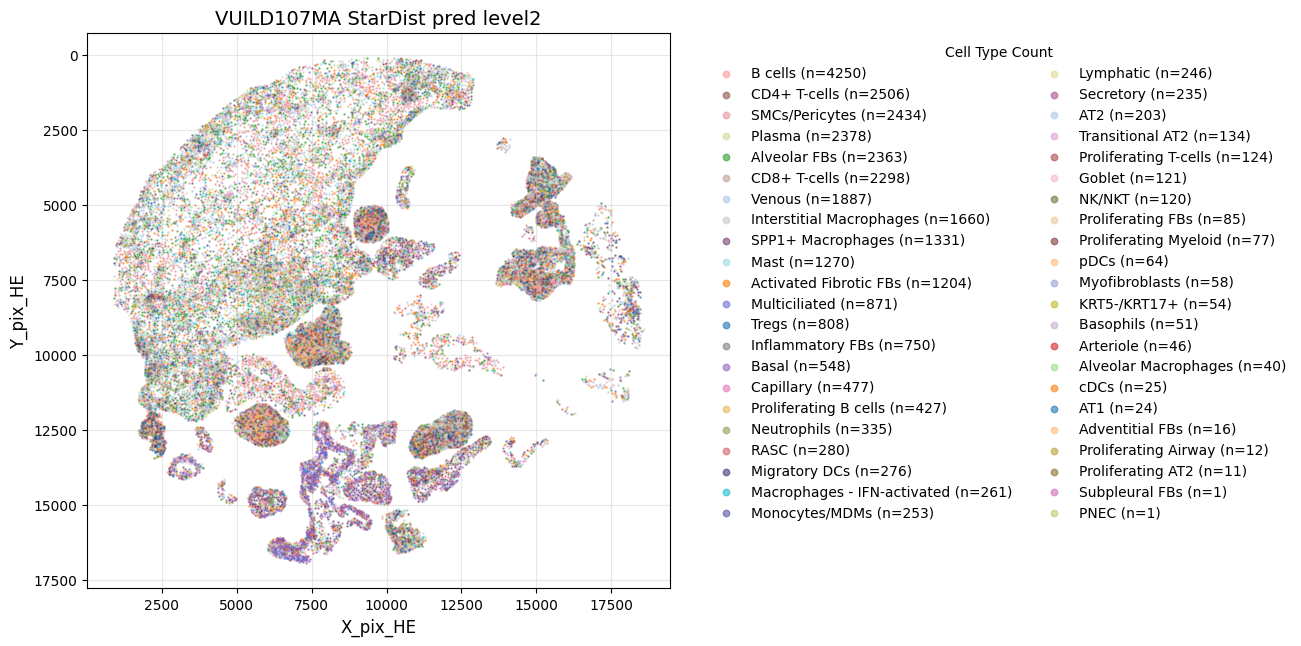


Plotting spatial distribution of TRUE level2 cell types...
Number of valid data points: 30615
Number of cell types: 45


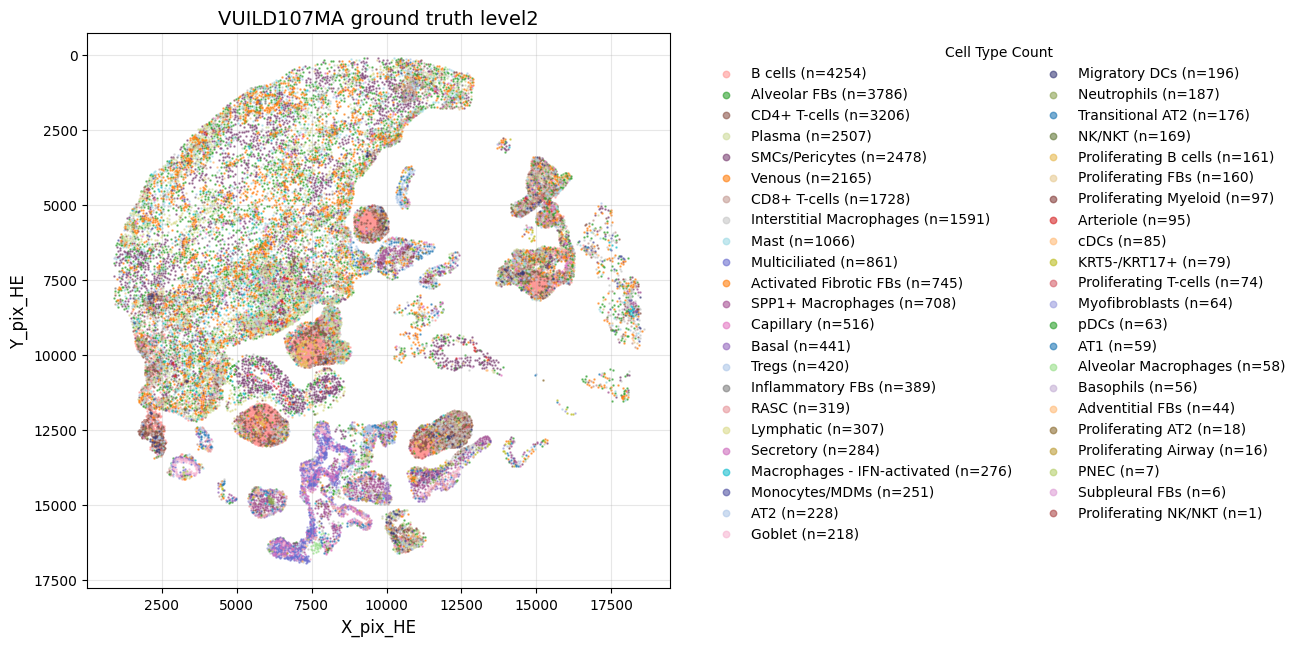

In [18]:
class_names_star = globals().get("class_names_star")
if class_names_star is None:
    class_names_star = class_names

all_acc, all_macro_f1, all_weighted_f1, all_preds, all_labels = evaluate_and_plot_on_all_data(
    model=model_star,
    matched_features_path=matched_features_stardist_path,
    class_names=class_names_star,
    evaluate=evaluate,
    plot_celltype_spatial_distribution=plot_celltype_spatial_distribution,
    CellTypeDataset=CellTypeDataset,
    device=device,
    scaler=scaler,
    val_loader=None,
    prediction_only=True,
    X_coords_matched=X_coords_star if "X_coords_star" in globals() else None,
    celltype_pred_dir=result_fig("stardist_pred_level2"),
    # celltype_true_dir=result_fig("stardist_true_level2"),
    spatial_plot_mode="pred_true_l2",
    spatial_color_scheme="xenium_ct",
    spatial_title_pred_l2=f"{therapy_data} StarDist pred level2",
    spatial_title_true_l2=f"{therapy_data} ground truth level2",
    celltype_pixel_NCRT_tumor1=celltype_pixel_NCRT_tumor1 if "celltype_pixel_NCRT_tumor1" in globals() else None,
)


  Level1 spatial plot: Xenium lineage colors (final_lineage palette).
Number of valid data points: 30615
Number of cell types: 4


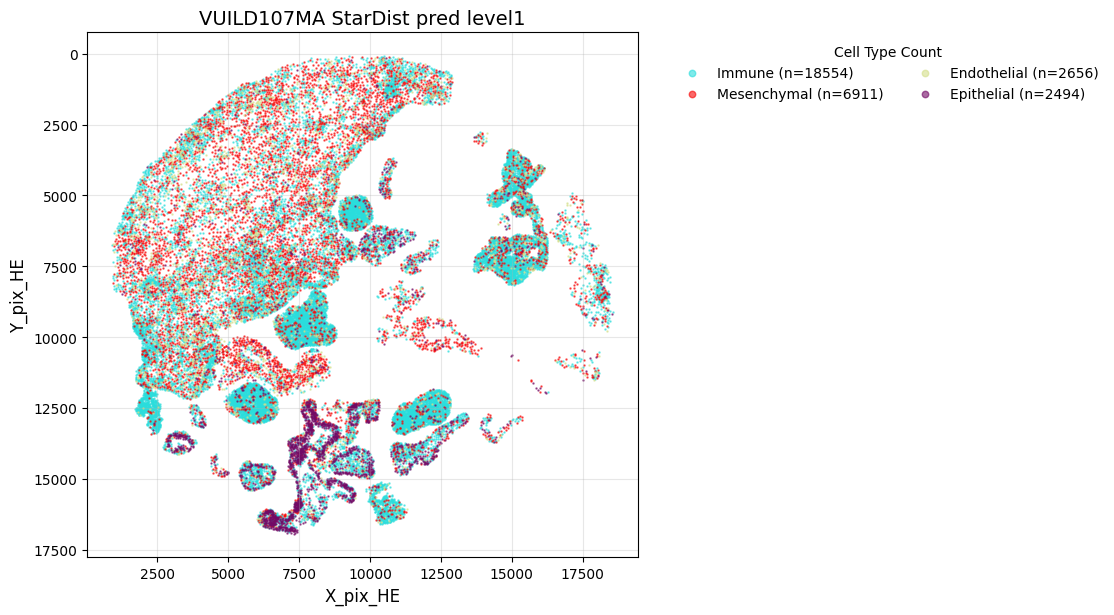

  Saved level1 predicted spatial plot: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/Xemiun/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases_Select4/VUILD107MA/VUILD107MA_project_all_UNI/result/celltype_pred_stardist_level1.jpg
Number of valid data points: 30615
Number of cell types: 4


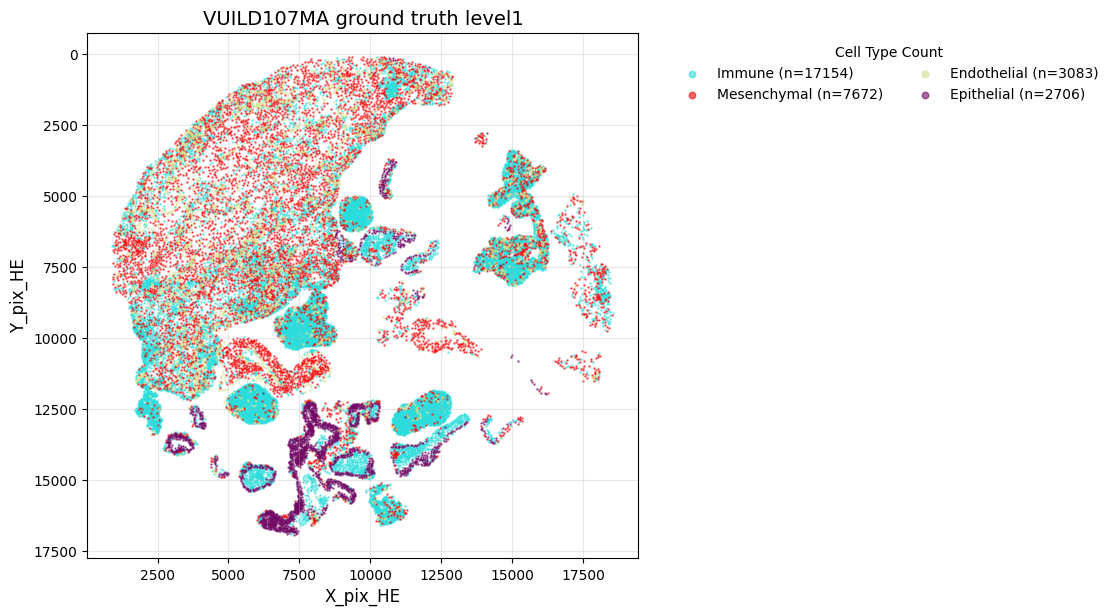

Saved: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/Xemiun/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases_Select4/VUILD107MA/VUILD107MA_project_all_UNI/result/celltype_pred_stardist_level1.jpg


In [19]:
# L2→L1 mapping comes from HE cv_data (same class_names / le_* as the trained model).
# Do not le_level2.transform(y_star): StarDist matched cells can include CT labels absent from training.
plot_level1_spatial_distribution(
    matched_features_path=matched_features_stardist_path,
    all_preds=all_preds,
    class_names_level1=class_names_level1,
    class_names=class_names,
    y_encoded_f=y_encoded_f,
    y_level1_encoded_f=y_level1_encoded_f,
    plot_celltype_spatial_distribution=plot_celltype_spatial_distribution,
    save_path_pred=result_fig("stardist_pred_level1"),
    # save_path_true=result_fig("stardist_true_level1"),
    spatial_color_scheme="xenium_lineage",
    fig_size=(10, 8),
    show=True,
    X_coords_matched=X_coords_star,
    y_level1_f=y_star_level1,
    spatial_title_pred_l1=f"{therapy_data} StarDist pred level1",
    spatial_title_true_l1=f"{therapy_data} ground truth level1",
)
print(f"Saved: {result_fig('stardist_pred_level1')}")


Visualizing per-class accuracy...
  ✓ Computed metrics for 45 classes


Figure saved to /home/lingyu/ssd2/Python/Collaborate/esccAI/data/Xemiun/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases_Select4/VUILD107MA/VUILD107MA_project_all_UNI/result/acc_level2_stardist.pdf


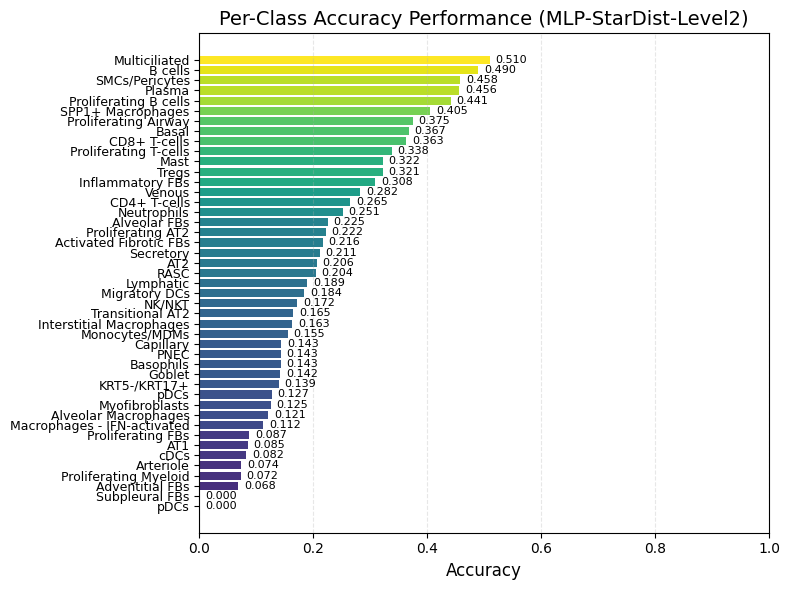


Model Summary:
  Device: cuda:2
  Total classes (before filtering): 44
  Actual classes in test set: 45
  Model parameters: 1,721,648
  Test Accuracy: 0.3249
  Test Macro F1: 0.2222
  Test Weighted F1: 0.3261
Saved: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/Xemiun/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases_Select4/VUILD107MA/VUILD107MA_project_all_UNI/result/acc_level2_stardist.pdf
  Level1 metrics from level2 preds: acc=0.7167, macro_f1=0.6104, weighted_f1=0.7102
Visualizing per-class accuracy...
  ✓ Computed metrics for 4 classes
Figure saved to /home/lingyu/ssd2/Python/Collaborate/esccAI/data/Xemiun/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases_Select4/VUILD107MA/VUILD107MA_project_all_UNI/result/acc_level1_stardist.pdf


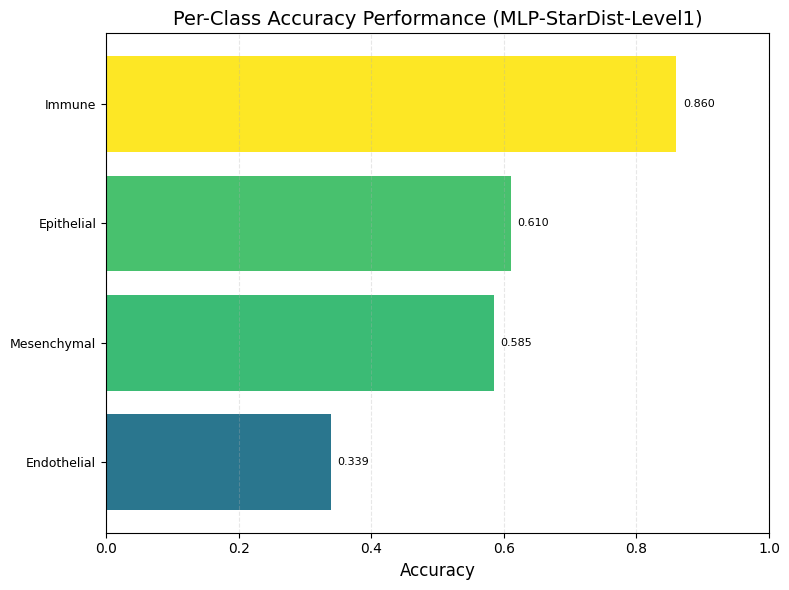


Model Summary:
  Device: cuda:2
  Total classes (before filtering): 4
  Actual classes in test set: 4
  Model parameters: 1,721,648
  Test Accuracy: 0.7167
  Test Macro F1: 0.6104
  Test Weighted F1: 0.7102
Saved: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/Xemiun/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases_Select4/VUILD107MA/VUILD107MA_project_all_UNI/result/acc_level1_stardist.pdf
  Level1 metrics from L1 head: acc=0.7131, macro_f1=0.6155, weighted_f1=0.7130
Visualizing per-class accuracy...
  ✓ Computed metrics for 4 classes
Figure saved to /home/lingyu/ssd2/Python/Collaborate/esccAI/data/Xemiun/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases_Select4/VUILD107MA/VUILD107MA_project_all_UNI/result/acc_level1_stardist_L1head.pdf


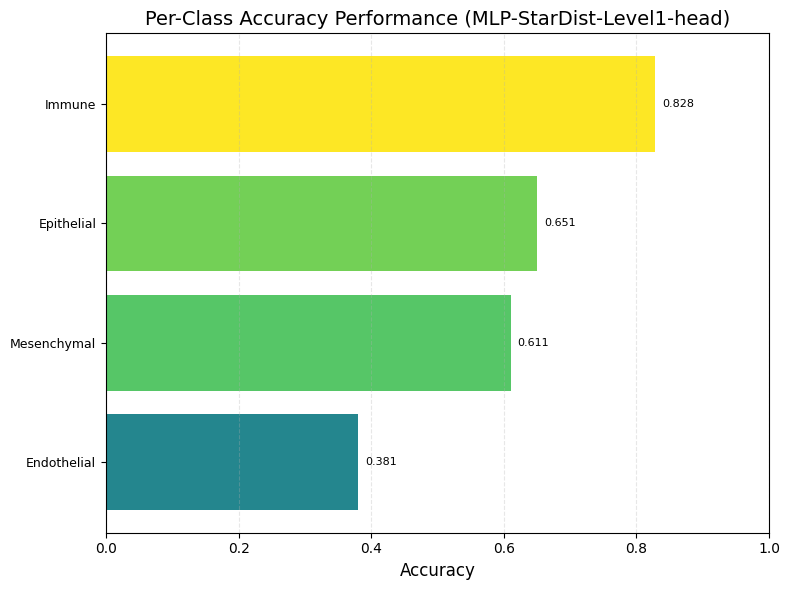


Model Summary:
  Device: cuda:2
  Total classes (before filtering): 4
  Actual classes in test set: 4
  Model parameters: 1,721,648
  Test Accuracy: 0.7131
  Test Macro F1: 0.6155
  Test Weighted F1: 0.7130
Saved: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/Xemiun/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases_Select4/VUILD107MA/VUILD107MA_project_all_UNI/result/acc_level1_stardist_L1head.pdf


In [20]:
## StarDist per-class accuracy (run after StarDist evaluate cell)
class_names_star = globals().get("class_names_star")
if class_names_star is None:
    class_names_star = class_names

metrics_acc_star = plot_per_class_accuracy(
    all_labels,
    all_preds,
    class_names_star,
    model=model_star,
    device=device,
    train_dataset=None,
    val_dataset=None,
    input_dim=None,
    best_epoch=None,
    test_acc=all_acc,
    test_macro_f1=all_macro_f1,
    test_weighted_f1=all_weighted_f1,
    model_name="MLP-StarDist-Level2",
    y_sort_by="acc_asc",
    save_path=result_fig("acc_level2_stardist"),
)
print(f"Saved: {result_fig('acc_level2_stardist')}")

# Level1 from L2 argmax → parent; mapping uses HE cv_data encodings (same class_names as model).
metrics_acc_star_l1 = plot_level1_accuracy_from_level2_predictions(
    matched_features_path=matched_features_stardist_path,
    all_preds=all_preds,
    class_names=class_names_star,
    class_names_level1=class_names_level1,
    y_encoded_f=y_encoded_f,
    y_level1_encoded_f=y_level1_encoded_f,
    plot_per_class_accuracy=plot_per_class_accuracy,
    model=model_star,
    device=device,
    model_name="MLP-StarDist-Level1",
    y_sort_by="acc_asc",
    save_path=result_fig("acc_level1_stardist"),
)
if metrics_acc_star_l1 is not None:
    print(f"Saved: {result_fig('acc_level1_stardist')}")

metrics_acc_star_l1_head = plot_level1_accuracy_from_level1_head(
    matched_features_path=matched_features_stardist_path,
    model=model_star,
    device=device,
    scaler=scaler,
    class_names_level1=class_names_level1,
    plot_per_class_accuracy=plot_per_class_accuracy,
    train_dataset=None,
    val_dataset=None,
    input_dim=None,
    best_epoch=None,
    model_name="MLP-StarDist-Level1-head",
    y_sort_by="acc_asc",
    save_path=result_fig("acc_level1_stardist_L1head"),
)
if metrics_acc_star_l1_head is not None:
    print(f"Saved: {result_fig('acc_level1_stardist_L1head')}")


Computing confusion matrix...
Figure saved to /home/lingyu/ssd2/Python/Collaborate/esccAI/data/Xemiun/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases_Select4/VUILD107MA/VUILD107MA_project_all_UNI/result/conf_matrix_level2_stardist.pdf


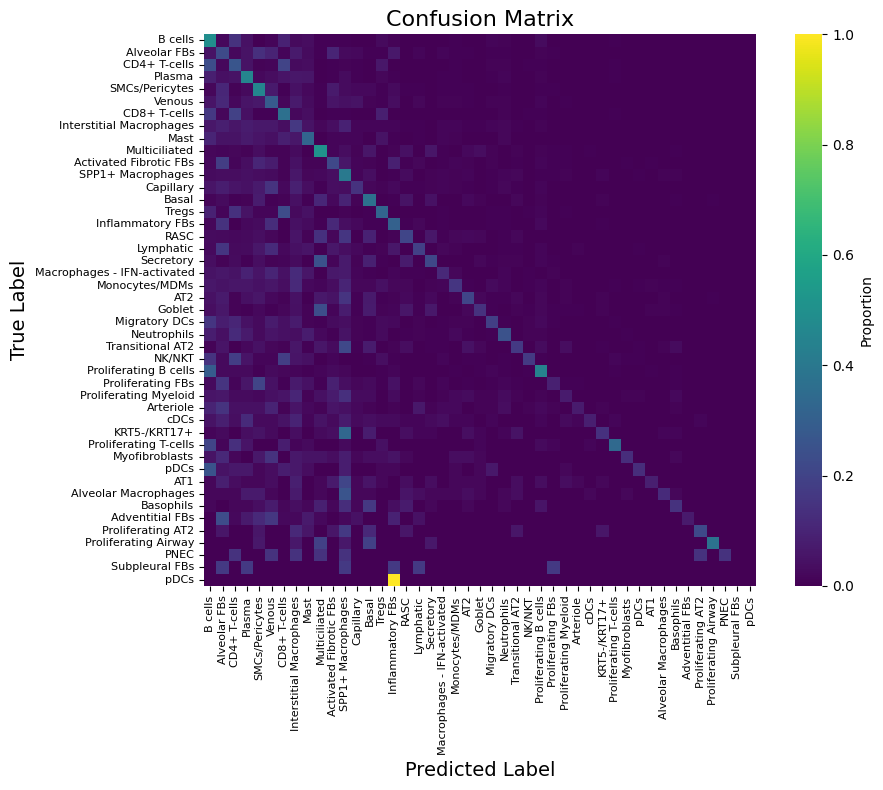

Computing confusion matrix...
Figure saved to /home/lingyu/ssd2/Python/Collaborate/esccAI/data/Xemiun/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases_Select4/VUILD107MA/VUILD107MA_project_all_UNI/result/conf_matrix_level1_stardist.pdf


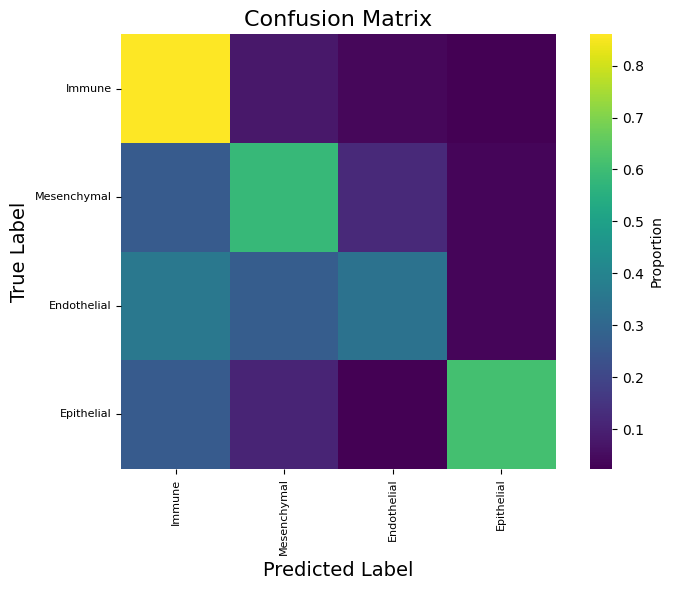

In [21]:
# StarDist prediction heatmaps (confusion matrices): level2 + level1
class_names_star = globals().get("class_names_star")
if class_names_star is None:
    class_names_star = class_names

plot_confusion_matrix(
    all_labels,
    all_preds,
    class_names_star,
    figsize=(10, 8),
    save_path=result_fig("conf_matrix_level2_stardist"),
)

_loaded_star = np.load(matched_features_stardist_path, allow_pickle=True)
if "y_level1" in _loaded_star:
    _y_true_l1_raw = _loaded_star["y_level1"]
    _child_to_parent = np.full(len(class_names_star), -1, dtype=np.int64)
    for _l2, _l1 in zip(y_encoded_f, y_level1_encoded_f):
        _l2_i, _l1_i = int(_l2), int(_l1)
        if _child_to_parent[_l2_i] == -1:
            _child_to_parent[_l2_i] = _l1_i
    _preds_l1 = _child_to_parent[np.asarray(all_preds, dtype=np.int64)]

    if getattr(_y_true_l1_raw, "dtype", None) is not None and _y_true_l1_raw.dtype.kind in ["U", "S", "O"]:
        _name_to_idx = {str(c): i for i, c in enumerate(class_names_level1)}
        _y_true_l1 = np.array([_name_to_idx.get(str(v), -1) for v in _y_true_l1_raw], dtype=np.int64)
    else:
        _y_true_l1 = np.asarray(_y_true_l1_raw, dtype=np.int64)

    _n = min(len(_y_true_l1), len(_preds_l1))
    _y_true_l1 = _y_true_l1[:_n]
    _preds_l1 = _preds_l1[:_n]
    _valid = _y_true_l1 >= 0

    if np.any(_valid):
        plot_confusion_matrix(
            _y_true_l1[_valid],
            _preds_l1[_valid],
            class_names_level1,
            figsize=(8, 6),
            save_path=result_fig("conf_matrix_level1_stardist"),
            # save_path=f'{therapy_data}/{therapy_model}/{save_result}/conf_matrix_tumor1_level1_stardist_hce.pdf',
        )
    else:
        print("Skip level1 StarDist confusion matrix: no valid y_level1 labels.")
else:
    print(f"Skip level1 StarDist confusion matrix: y_level1 not found in {matched_features_stardist_path}")


Visualizing per-class performance...
  ✓ Computed metrics for 45 classes
Figure saved to /home/lingyu/ssd2/Python/Collaborate/esccAI/data/Xemiun/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases_Select4/VUILD107MA/VUILD107MA_project_all_UNI/result/f1_level2_stardist.pdf


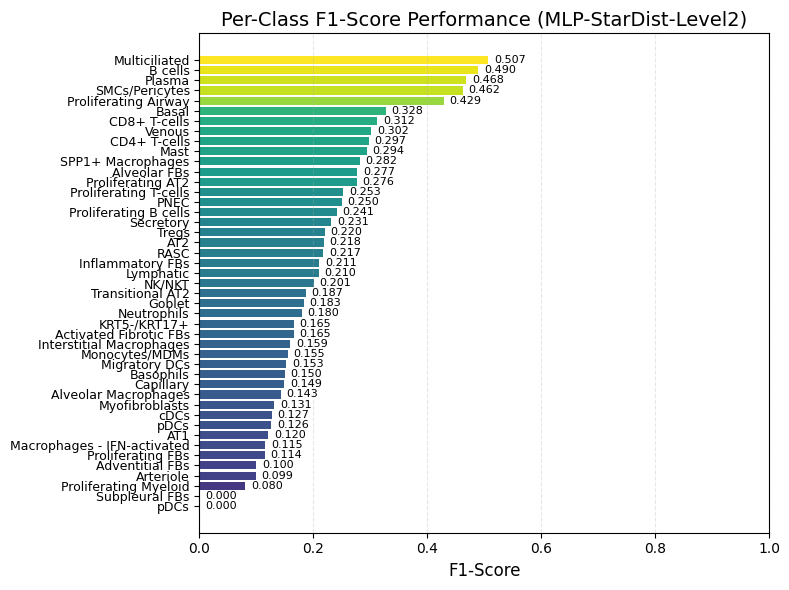


Model Summary:
  Device: cuda:2
  Total classes (before filtering): 44
  Actual classes in test set: 45
  Model parameters: 1,721,648
  Test Accuracy: 0.3249
  Test Macro F1: 0.2222
  Test Weighted F1: 0.3261
  Level1 F1 plot from level2 preds (same mapping as accuracy helper): acc=0.7167, macro_f1=0.6104, weighted_f1=0.7102
Visualizing per-class performance...
  ✓ Computed metrics for 4 classes
Figure saved to /home/lingyu/ssd2/Python/Collaborate/esccAI/data/Xemiun/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases_Select4/VUILD107MA/VUILD107MA_project_all_UNI/result/f1_level1_stardist.pdf


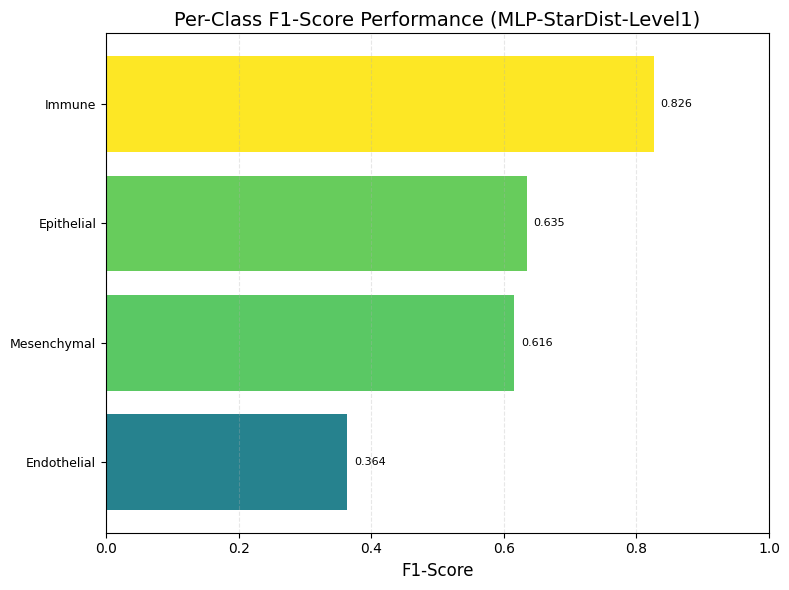


Model Summary:
  Device: cuda:2
  Total classes (before filtering): 4
  Actual classes in test set: 4
  Model parameters: 1,721,648
  Test Accuracy: 0.7167
  Test Macro F1: 0.6104
  Test Weighted F1: 0.7102
  Level1 F1 plot from L1 head: acc=0.7131, macro_f1=0.6155, weighted_f1=0.7130
Visualizing per-class performance...
  ✓ Computed metrics for 4 classes
Figure saved to /home/lingyu/ssd2/Python/Collaborate/esccAI/data/Xemiun/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases_Select4/VUILD107MA/VUILD107MA_project_all_UNI/result/f1_level1_stardist_L1head.pdf


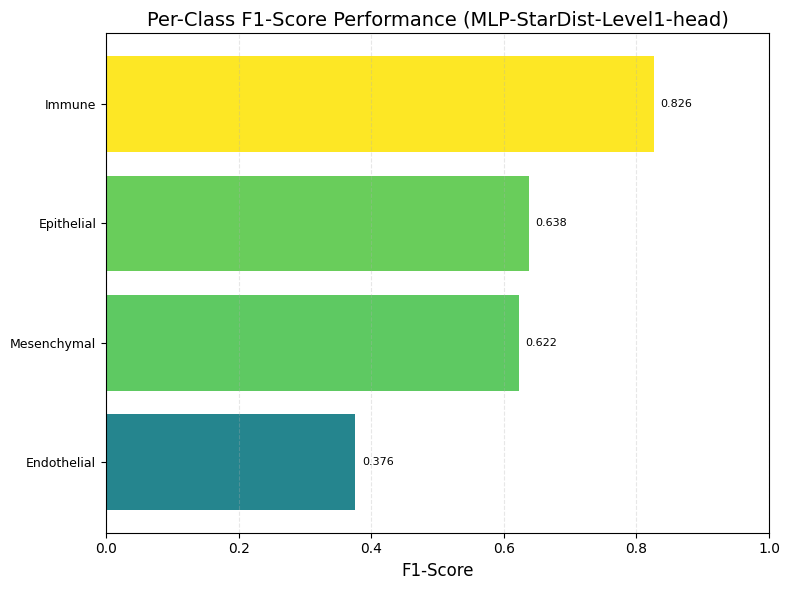


Model Summary:
  Device: cuda:2
  Total classes (before filtering): 4
  Actual classes in test set: 4
  Model parameters: 1,721,648
  Test Accuracy: 0.7131
  Test Macro F1: 0.6155
  Test Weighted F1: 0.7130


In [22]:
class_names_star = globals().get("class_names_star")
if class_names_star is None:
    class_names_star = class_names

metrics_f1_star = plot_per_class_f1(
    all_labels,
    all_preds,
    class_names_star,
    model=model_star,
    device=device,
    train_dataset=None,
    val_dataset=None,
    input_dim=None,
    best_epoch=None,
    test_acc=all_acc,
    test_macro_f1=all_macro_f1,
    test_weighted_f1=all_weighted_f1,
    y_sort_by="f1_asc", 
    model_name="MLP-StarDist-Level2",
    save_path=result_fig("f1_level2_stardist"),
)

metrics_f1_star_l1 = plot_level1_f1_from_level2_predictions(
    matched_features_path=matched_features_stardist_path,
    all_preds=all_preds,
    class_names=class_names_star,
    class_names_level1=class_names_level1,
    y_encoded_f=y_encoded_f,
    y_level1_encoded_f=y_level1_encoded_f,
    plot_per_class_f1=plot_per_class_f1,
    model=model_star,
    device=device,
    y_sort_by="f1_asc", 
    model_name="MLP-StarDist-Level1",
    save_path=result_fig("f1_level1_stardist"),
)


metrics_f1_star_l1_head = plot_level1_f1_from_level1_head(
    matched_features_path=matched_features_stardist_path,
    model=model_star,
    device=device,
    scaler=scaler,
    class_names_level1=class_names_level1,
    plot_per_class_f1=plot_per_class_f1,
    train_dataset=None,
    val_dataset=None,
    input_dim=None,
    best_epoch=None,
    y_sort_by="f1_asc",
    model_name="MLP-StarDist-Level1-head",
    save_path=result_fig("f1_level1_stardist_L1head"),
)


  ROC colors: xenium_ct (aligned with Xenium spatial palette).
  ✓ Saved ROC figure: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/Xemiun/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases_Select4/VUILD107MA/VUILD107MA_project_all_UNI/result/roc_stardist_level2.pdf


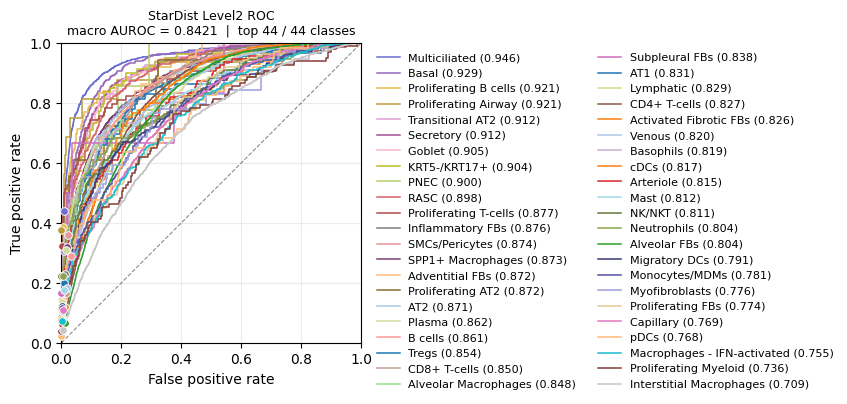

  ROC colors: xenium_lineage (aligned with Xenium spatial palette).
  ✓ Saved ROC figure: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/Xemiun/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases_Select4/VUILD107MA/VUILD107MA_project_all_UNI/result/roc_stardist_level1.pdf


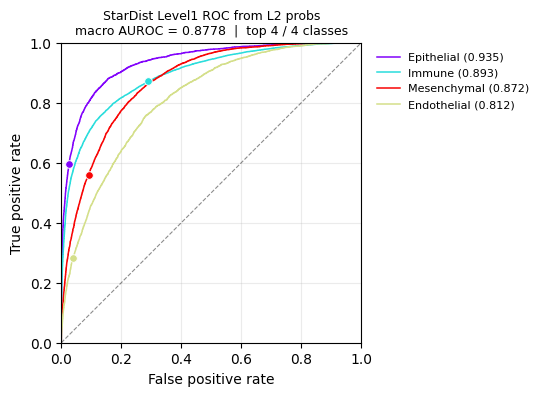

  ROC colors: xenium_lineage (aligned with Xenium spatial palette).
  ✓ Saved ROC figure: /home/lingyu/ssd2/Python/Collaborate/esccAI/data/Xemiun/weiqin/SpatialPF-NGenetics/Spatial-PF-Processed/Data/Complete_Cases_Select4/VUILD107MA/VUILD107MA_project_all_UNI/result/roc_stardist_level1_L1head.pdf


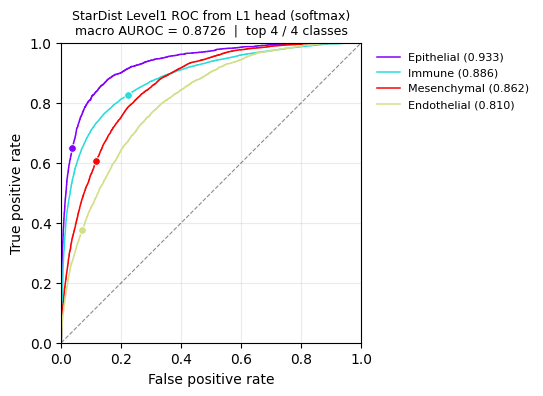

In [25]:
import numpy as np

class_names_star = globals().get("class_names_star")
if class_names_star is None:
    class_names_star = class_names

_z = np.load(matched_features_stardist_path)
X_star_scaled = scaler.transform(_z["X"])
probs_l2 = mlp_collect_softmax_probs(model_star, X_star_scaled, device)

# 与 evaluate_and_plot_on_all_data 得到的 all_labels 对齐长度
# ROC 曲线颜色与空间图一致：L2 用 xenium_ct（final_CT），L1 用 xenium_lineage
if all_labels is None:
    print("Skip ROC: no ground-truth labels (all_labels is None).")
else:
    m = min(len(probs_l2), len(all_labels))
    roc_info_l2 = plot_multiclass_roc_curves(
        all_labels[:m],
        probs_l2[:m],
        class_names_star,
        figsize=(3.0, 3.0),
        max_curves=len(class_names_star),
        save_path=result_fig("roc_stardist_level2"),
        title="StarDist Level2 ROC",
        roc_color_scheme="xenium_ct",
    )
    roc_info_l1 = plot_level1_roc_from_level2_scores(
        matched_features_stardist_path,
        probs_l2[:m],
        class_names_star,
        class_names_level1,
        y_encoded_f,
        y_level1_encoded_f,
        figsize=(3.0, 3.0),
        save_path=result_fig("roc_stardist_level1"),
        title="StarDist Level1 ROC from L2 probs",
        roc_color_scheme="xenium_lineage",
    )

    roc_info_l1_head = plot_level1_roc_from_level1_head(
        matched_features_stardist_path,
        model_star,
        device,
        scaler,
        class_names_level1,
        figsize=(3.0, 3.0),
        n_rows_max=m,
        save_path=result_fig("roc_stardist_level1_L1head"),
        title="StarDist Level1 ROC from L1 head (softmax)",
        roc_color_scheme="xenium_lineage",
    )
